In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Dataset/pizza_sales.csv')
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [3]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


# Convert date and time columsn to date time

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

In [9]:
df['order_time'] = pd.to_datetime(df['order_time'], format='mixed')

# Extract day, month and hour from data

In [10]:
df['order_day'] = df['order_date'].dt.day_name()

In [11]:
weekdays = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['order_day'] = pd.Categorical(df['order_day'], categories=weekdays)

In [12]:
df['order_month'] = df['order_date'].dt.month_name()

In [13]:
df['order_hour'] = df['order_time'].dt.hour

# KPIs (Key Performance Indicator)

In [14]:
# •	Total Revenue = Sum of total_price
total_revenue = df['total_price'].sum()

# •	Total Pizzas Sold = Sum of quantity
total_pizza_sold = df['quantity'].sum()

# •	Total Orders = Count of unique order_id
total_orders = df['order_id'].nunique() # count number of unique values

# •	Average Order Value (AOV) = Total Revenue ÷ Total Orders
avg_order_value = total_revenue / total_orders

# •	Average Pizza per Order = Total Pizzas Sold ÷ Total Orders
avg_pizza_per_order = total_pizza_sold/total_orders

In [15]:
print(f'Total Revenue: Rs.{round(total_revenue, 2)}')
print(f'Total Pizzas Sold: {total_pizza_sold} qty')
print(f'Total Orders: {total_orders}')
print(f'Average Order Value: Rs.{round(avg_order_value, 2)}')
print(f'Average Pizza Per Order: {round(avg_pizza_per_order, 2)} qty')

Total Revenue: Rs.817860.05
Total Pizzas Sold: 49574 qty
Total Orders: 21350
Average Order Value: Rs.38.31
Average Pizza Per Order: 2.32 qty


In [16]:
# sales by day of the week
day_sales = df.groupby('order_day', observed=False)['total_price'].sum().reset_index()
day_sales

,order_day,total_price
0,Sunday,99203.50
1,Monday,107329.55
2,Tuesday,114133.80
3,Wednesday,114408.40
4,Thursday,123528.50
5,Friday,136073.90
6,Saturday,123182.40


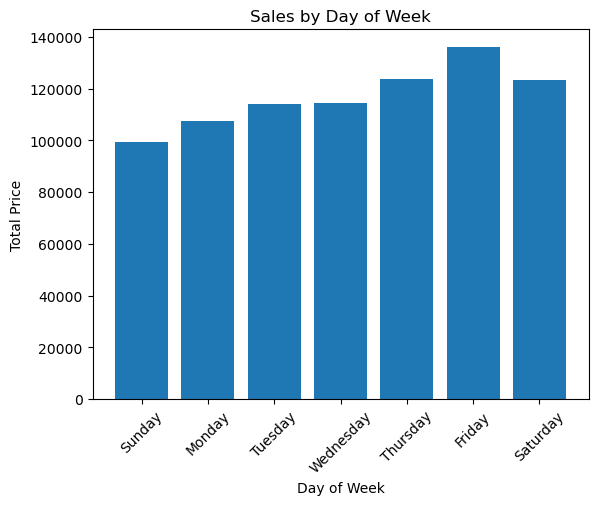

In [29]:
plt.bar(day_sales['order_day'], day_sales['total_price'])
plt.xlabel('Day of Week')
plt.ylabel('Total Price')
plt.title('Sales by Day of Week')
plt.xticks(rotation=45)
plt.show()

In [17]:
# Sales by hour of the day
hour_sales = df.groupby('order_hour')['total_price'].sum().reset_index()
hour_sales

,order_hour,total_price
0,9,83.00
1,10,303.65
2,11,44935.80
3,12,111877.90
4,13,106065.70
5,14,59201.40
6,15,52992.30
7,16,70055.40
8,17,86237.45
9,18,89296.85


In [18]:
# monthly revenue and orders.
monthly_report = df.groupby('order_month').agg(
    total_revenue = ('total_price', 'sum'),
    total_orders = ('order_id', 'nunique')
).reset_index()
monthly_report

,order_month,total_revenue,total_orders
0,April,68736.80,1799
1,August,68278.25,1841
2,December,64701.15,1680
3,February,65159.60,1685
4,January,69793.30,1845
5,July,72557.90,1935
6,June,68230.20,1773
7,March,70397.10,1840
8,May,71402.75,1853
9,November,70395.35,1792


In [19]:
# % of Sales by Category
sales_cat_pct = df.groupby('pizza_category')['total_price'].sum().reset_index()
sales_cat_pct['price_pct'] = (sales_cat_pct['total_price']/total_revenue)*100
sales_cat_pct

,pizza_category,total_price,price_pct
0,Chicken,195919.50,23.955138
1,Classic,220053.10,26.905960
2,Supreme,208197.00,25.456311
3,Veggie,193690.45,23.682591


In [20]:
# % Sales by Pizza Size & Category
size_cat_pct = df.groupby(['pizza_size', 'pizza_category'])['total_price'].sum().reset_index()
size_cat_pct['price_pct'] = (size_cat_pct['total_price']/total_revenue)*100
size_cat_pct

,pizza_size,pizza_category,total_price,price_pct
0,L,Chicken,102339.00,12.513021
1,L,Classic,74518.50,9.111400
2,L,Supreme,94258.50,11.525016
3,L,Veggie,104202.70,12.740896
4,M,Chicken,65224.50,7.975020
5,M,Classic,60581.75,7.407349
6,M,Supreme,66475.00,8.127919
7,M,Veggie,57101.00,6.981757
8,S,Chicken,28356.00,3.467097
9,S,Classic,69870.25,8.543057


In [21]:
# Total Pizzas Sold by Pizza Category
pizza_sold_cat = df.groupby('pizza_category')['quantity'].sum().reset_index()
pizza_sold_cat

,pizza_category,quantity
0,Chicken,11050
1,Classic,14888
2,Supreme,11987
3,Veggie,11649


In [22]:
# Top 5 Best-Selling Pizzas
top_best = df.groupby('pizza_name').agg(
    total_sales = ('total_price', 'sum'),
    total_orders = ('order_id', 'nunique'),
    total_quantity = ('quantity', 'sum')
).sort_values(ascending=False, by='total_sales').head().reset_index()
top_best

,pizza_name,total_sales,total_orders,total_quantity
0,The Thai Chicken Pizza,43434.25,2225,2371
1,The Barbecue Chicken Pizza,42768.00,2273,2432
2,The California Chicken Pizza,41409.50,2197,2370
3,The Classic Deluxe Pizza,38180.50,2329,2453
4,The Spicy Italian Pizza,34831.25,1822,1924


In [23]:
# least 5 Best-Selling Pizzas
least_selling = df.groupby('pizza_name').agg(
    total_sales = ('total_price', 'sum')
).sort_values(ascending=True, by='total_sales').head().reset_index()
least_selling

,pizza_name,total_sales
0,The Brie Carre Pizza,11588.50
1,The Green Garden Pizza,13955.75
2,The Spinach Supreme Pizza,15277.75
3,The Mediterranean Pizza,15360.50
4,The Spinach Pesto Pizza,15596.00
